In [2]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 700.4 kB/s eta 0:02:25
   ---------------------------------------- 0.8/101.7 MB 1.1 MB/s eta 0:01:34
    --------------------------------------- 1.3/101.7 MB 1.5 MB/s eta 0:01:07
    --------------------------------------- 1.3/101.7 MB 1.5 MB/s eta 0:01:07
    --------------------------------------- 1.6/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.8/101.7 MB 1.2 MB/s eta 0:01:25
   - -------------------------------------- 2.6/101.7 MB 1.5 MB/s eta 0:01:07
   - --------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import RandomizedSearchCV

import joblib
from pathlib import Path

In [2]:
# ===============================
# 2. PATHS
# ===============================
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "Dataset"
MODELS_PATH = PROJECT_ROOT / "models"
MODELS_PATH.mkdir(exist_ok=True)

# ===============================
# 3. LOAD DATA
# ===============================
X_train = joblib.load(DATA_PATH / "X_train.pkl")
X_test = joblib.load(DATA_PATH / "X_test.pkl")
y_train = joblib.load(DATA_PATH / "y_train.pkl")
y_test = joblib.load(DATA_PATH / "y_test.pkl")

tfidf = joblib.load(DATA_PATH / "tfidf_vectorizer.pkl")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6017, 329)
Test shape: (1505, 329)


In [3]:
# ===============================
# 4. HANDLE MISSING VALUES
# ===============================

medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

In [4]:
# ===============================
# 5. SCALE FEATURES (FOR LR)
# ===============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# ---- Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [6]:
# ---- Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [7]:
# ===============================
# 8. XGBOOST (VERSION-SAFE)
# ===============================
xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    reg_alpha=0.5,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [8]:
# ===============================
# 9. EVALUATION FUNCTION
# ===============================
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{name} Performance:")
    print("RMSE:", round(rmse, 4))
    print("MAE :", round(mae, 4))
    print("R2  :", round(r2, 4))
    print("-" * 40)


evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("XGBoost", y_test, xgb_pred)

Linear Regression Performance:
RMSE: 0.414
MAE : 0.3147
R2  : 0.6438
----------------------------------------
Random Forest Performance:
RMSE: 0.411
MAE : 0.3088
R2  : 0.6489
----------------------------------------
XGBoost Performance:
RMSE: 0.4013
MAE : 0.3048
R2  : 0.6654
----------------------------------------


In [9]:
# ===============================
# 10. REAL SALARY COMPARISON
# ===============================
rf_salary_pred = np.expm1(rf_pred)
xgb_salary_pred = np.expm1(xgb_pred)
actual_salary = np.expm1(y_test)

rf_real_rmse = np.sqrt(mean_squared_error(actual_salary, rf_salary_pred))
xgb_real_rmse = np.sqrt(mean_squared_error(actual_salary, xgb_salary_pred))

print("Random Forest RMSE (Real Salary):", round(rf_real_rmse, 2))
print("XGBoost RMSE (Real Salary):", round(xgb_real_rmse, 2))

Random Forest RMSE (Real Salary): 274631.46
XGBoost RMSE (Real Salary): 270387.3


In [10]:
# ===============================
# 11. OVERFITTING CHECK
# ===============================
train_pred = xgb.predict(X_train)

print("Train R2:", round(r2_score(y_train, train_pred), 4))
print("Test R2 :", round(r2_score(y_test, xgb_pred), 4))

Train R2: 0.7423
Test R2 : 0.6654


In [11]:
# ===============================
# HYPERPARAMETER SEARCH SPACE
# ===============================
param_dist = {
    "n_estimators": [300, 400, 500, 600, 700],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1, 2, 5],
    "reg_alpha": [0, 0.5, 1]
}

In [12]:
# ===============================
# BASE MODEL
# ===============================
xgb_base = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

In [13]:
# ===============================
# RANDOMIZED SEARCH WITH CV
# ===============================
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,              # number of random combinations
    scoring="r2",
    cv=5,                   # 5-fold cross validation
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [300, 400, ...], ...}"
,n_iter,25
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [14]:
# ===============================
# BEST MODEL
# ===============================
best_xgb = random_search.best_estimator_

print("\nBest Parameters Found:")
print(random_search.best_params_)

print("\nBest CV R2 Score:")
print(round(random_search.best_score_, 4))

# ===============================
# TEST SET PERFORMANCE
# ===============================
xgb_pred = best_xgb.predict(X_test)

print("\nTest R2:", round(r2_score(y_test, xgb_pred), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, xgb_pred)), 4))


Best Parameters Found:
{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best CV R2 Score:
0.6598

Test R2: 0.6735
Test RMSE: 0.3964


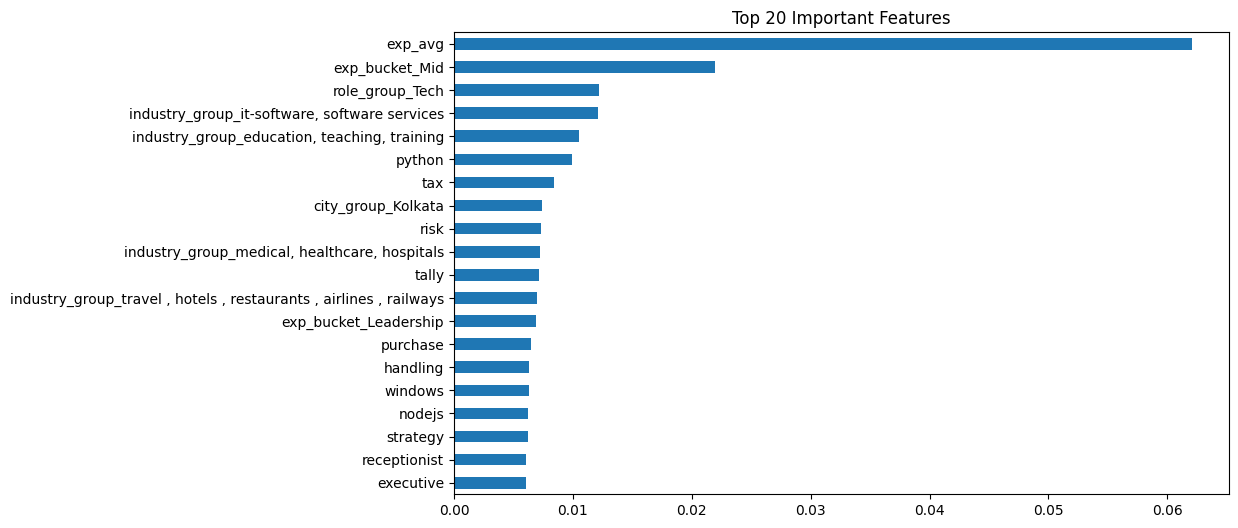

In [15]:
# ===============================
# 12. FEATURE IMPORTANCE
# ===============================
importance = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importance, index=feature_names)
top_features = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh")
plt.title("Top 20 Important Features")
plt.gca().invert_yaxis()
plt.show()


In [16]:
train_pred = best_xgb.predict(X_train)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, xgb_pred))

Train R2: 0.7805704482299829
Test R2 : 0.6735236083574785


In [17]:
# ===============================
# 13. SAVE MODEL & ARTIFACTS
# ===============================
joblib.dump(best_xgb, MODELS_PATH / "salary_model.pkl")
joblib.dump(tfidf, MODELS_PATH / "tfidf_vectorizer.pkl")
joblib.dump(scaler, MODELS_PATH / "scaler.pkl")
joblib.dump(medians, MODELS_PATH / "medians.pkl")

print("\nModel and artifacts saved successfully.")


Model and artifacts saved successfully.
